In [3]:
# 필요한 패키지 설치
# !pip install xverse
from xverse.transformer import WOE
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams['figure.dpi'] = 300

In [14]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
df = pd.read_csv("../../main/datasets/heart_2020_cleaned.csv")

# 데이터 샘플 확인
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [15]:
# BMI 컬럼의 분포 확인

df['BMI'].describe()

count    319795.000000
mean         28.325399
std           6.356100
min          12.020000
25%          24.030000
50%          27.340000
75%          31.420000
max          94.850000
Name: BMI, dtype: float64

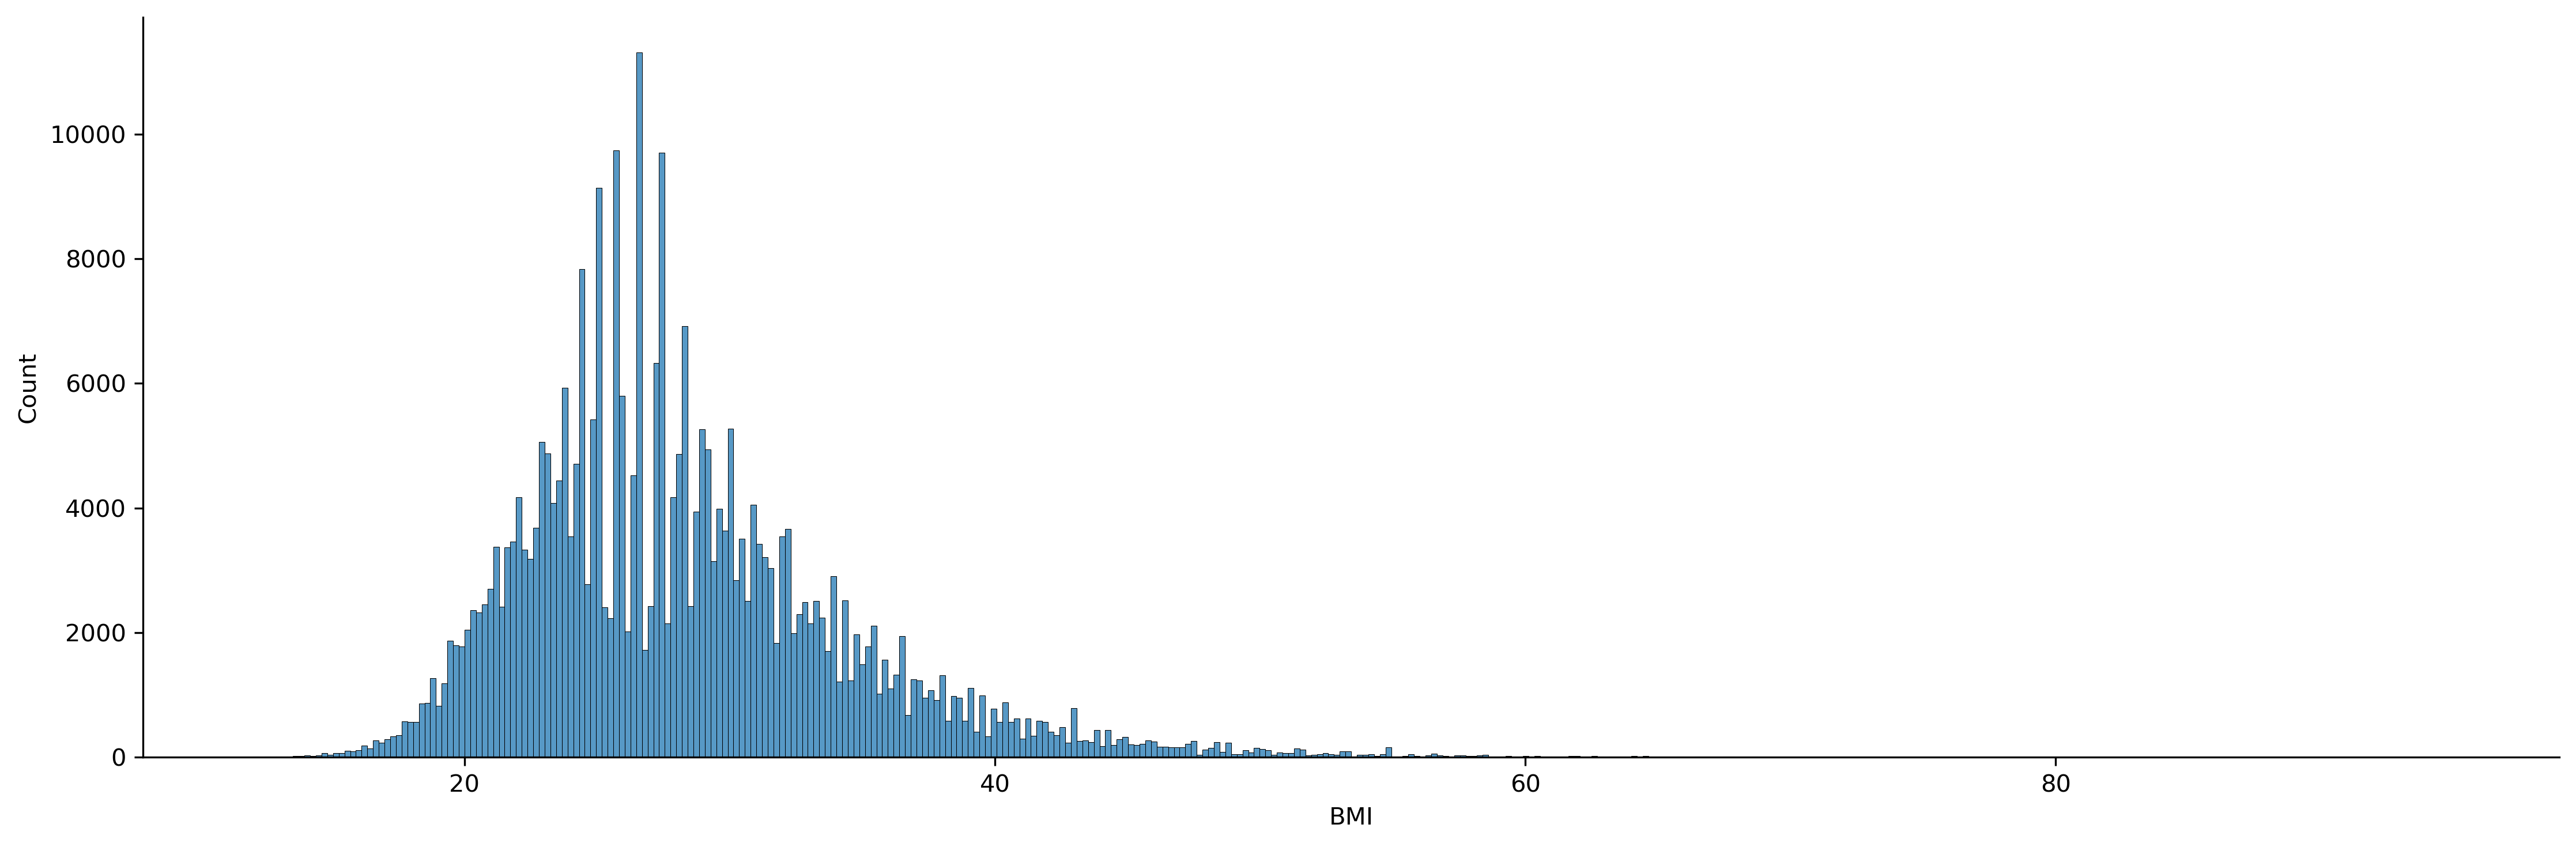

In [ ]:
# BMdisplot() 함수를 이용해, 데이터프레임 df 안에 있는 'BMI' 컬럼의 분포를 시각화

%matplotlib inline
sns.displot(df['BMI'],height = 5, aspect = 3)
# height=5	플롯의 **높이(inch 단위)**를 5로 설정
# aspect=3	플롯의 가로:세로 비율을 3으로 설정합니다 → 결과적으로 가로 폭 = 5 × 3 = 15 inch

In [ ]:
# 임의로 단순 구간화

df1 = df.copy() # 데이터셋 복사

# 구간화용 빈 컬럼 생성 - 생략해도 되지만 바로 옆에 붙여 보기 위함
df1.insert(2, 'BMI_bin', 0) 
# df1 데이터프레임의 세 번째 열(index=2) 위치에 새로운 열을 삽입
# 새로운 열의 이름은 'BMI_bin'이며, 모든 행에 대해 초기값으로 0이 들어감
# 즉, 'BMI_bin'이라는 이름의 열을 추가하고, 그 열의 모든 값은 0으로 설정

df1.loc[df1['BMI'] <= 20, 'BMI_bin'] = 'a'
df1.loc[(df1['BMI'] > 20) & (df1['BMI'] <= 30), 'BMI_bin'] = 'b'
df1.loc[(df1['BMI'] > 30) & (df1['BMI'] <= 40), 'BMI_bin'] = 'c'
df1.loc[(df1['BMI'] > 40) & (df1['BMI'] <= 50), 'BMI_bin'] = 'd'
df1.loc[(df1['BMI'] > 50) & (df1['BMI'] <= 60), 'BMI_bin'] = 'e'
df1.loc[(df1['BMI'] > 60) & (df1['BMI'] <= 70), 'BMI_bin'] = 'f'
df1.loc[df1['BMI'] > 70, 'BMI_bin'] = 'g'

df1.head()

/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_86778/3085778236.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'a' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1.loc[df1['BMI'] <= 20, 'BMI_bin'] = 'a'


,HeartDisease,BMI,BMI_bin,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,a,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,b,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,b,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,b,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,b,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


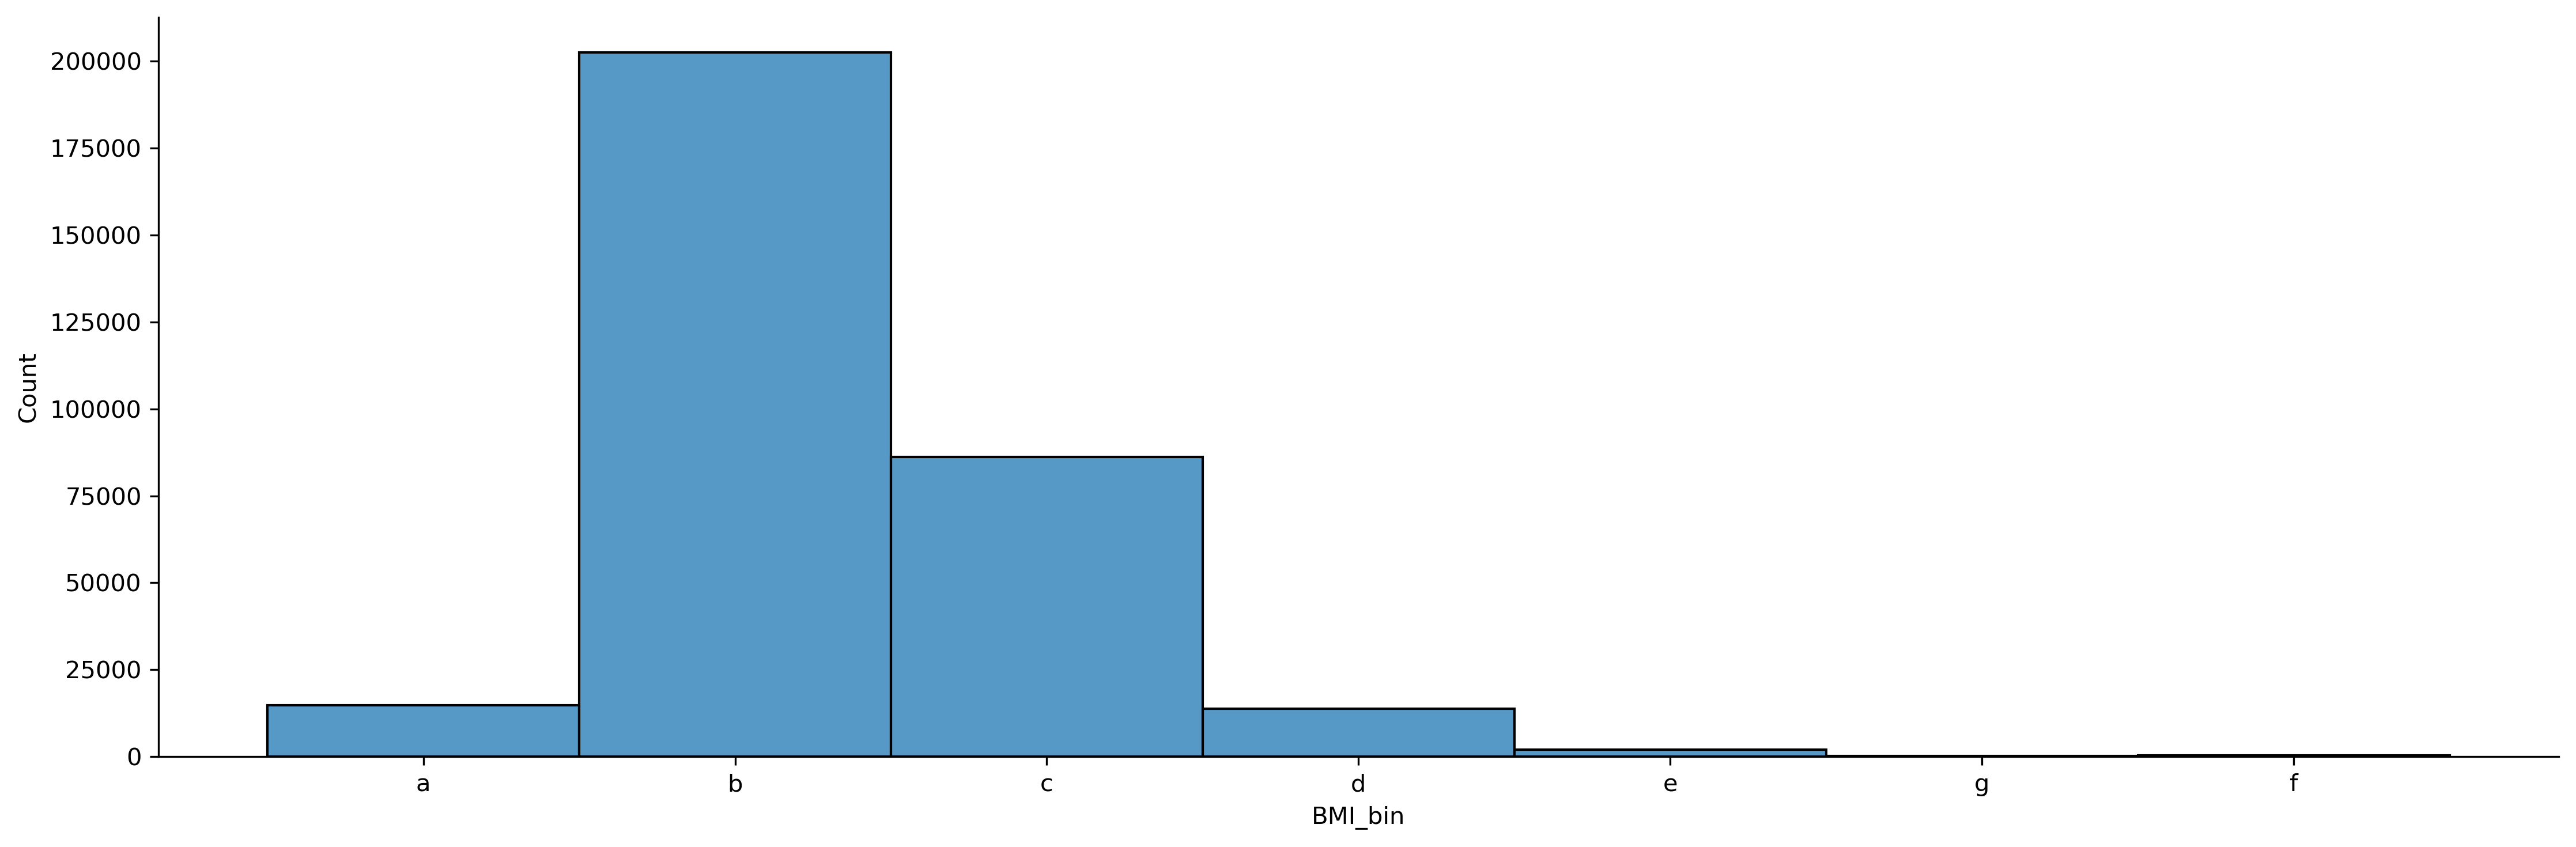

In [18]:
# 구간화 변수 분포 시각화

sns.displot(df1['BMI_bin'],height = 5, aspect = 3)

In [ ]:
#  cut() 함수 사용하여 임의로 구간화
df1.insert(3, 'BMI_bin2', 0) # 구간화용 빈 컬럼 생성 

# pd.cut()은 연속형 데이터를 일정 구간으로 나눌 때 사용
# bins는 각 구간의 경계를 의미하며, [) 형태로 왼쪽 포함, 오른쪽 미포함
# labels는 각 구간에 대응되는 범주형 값
# 예를 들어 BMI가 25이면, [20~30) 구간이므로 'b' 라벨이 할당

df1['BMI_bin2'] = pd.cut(df1.BMI, bins=[0, 20, 30, 40, 50, 60, 70, 95]
                         , labels=['a', 'b', 'c', 'd', 'e', 'f', 'g'])

# df1의 'BMI' 값을 기준으로 특정 구간(bins)으로 나누어 범주형 변수로 변환
# 구간은 [0~20), [20~30), ..., [70~95) 총 7개로 나뉘며, 각 구간에 'a'부터 'g'까지의 라벨을 부여
# 결과는 새로운 열 'BMI_bin2'에 저장

df1.head()

,HeartDisease,BMI,BMI_bin,BMI_bin2,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,a,a,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,b,b,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,b,b,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,b,b,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,b,b,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [ ]:
# BMI_bin2 구간 별 관측치 수 집계

df1.BMI_bin2.value_counts().to_frame().style.background_gradient(cmap='winter')

# # 'BMI_bin2' 컬럼의 각 범주별 개수를 계산
# # value_counts()는 각 라벨(a~g)의 빈도를 반환
# df1.BMI_bin2.value_counts()

# # 위 결과를 DataFrame 형태로 변환 (기존에는 Series였음)
# # 열 이름이 없던 데이터를 하나의 열로 구성된 DataFrame으로 바꿈
# .to_frame()

# # 스타일을 적용하여 시각적으로 보기 좋게 만듬
# # background_gradient는 값이 큰 칸일수록 색이 진하게 표시되도록 함
# # cmap='winter'는 파란색 계열의 색상 맵을 사용
# .style.background_gradient(cmap='winter')

,count
BMI_bin2,
b,202548
c,86198
a,14699
d,13839
e,2019
f,363
g,129


In [ ]:
# qcut() 함수 사용하여 자동 구간화

# BMI를 자동으로 7개 구간으로 나누기 위한 컬럼 생성
df1.insert(4, 'BMI_bin3', 0)  # 5번째 열에 'BMI_bin3' 컬럼 삽입, 초기값 0 설정

# qcut()을 사용한 분위수 기반 구간화 수행
# BMI 값을 7개의 분위수로 분할하여 'a'부터 'g'까지 라벨 부여
# 라벨은 각 구간을 구분하기 위한 범주형 값으로 사용
df1['BMI_bin3'] = pd.qcut(df1.BMI, q=7, labels=['a', 'b', 'c', 'd', 'e', 'f', 'g'])
# qcut() 함수에서 사용하는 q는 quantile (분위수)의 약자
# 예를 들어 q=4이면, 전체 데이터를 4등분해서 각 구간에 데이터 수가 같도록 나눔
# 즉, 데이터의 값 크기 기준이 아니라, 개수 기준으로 나누는 방식
# q=7이면, 전체 데이터를 7등분하여 각 구간에 동일한 개수의 데이터가 들어가도록 구간을 설정

df1.head()

,HeartDisease,BMI,BMI_bin,BMI_bin2,BMI_bin3,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,...,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,a,a,a,Yes,No,No,3.0,30.0,...,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,b,b,a,No,No,Yes,0.0,0.0,...,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,b,b,d,Yes,No,No,20.0,30.0,...,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,b,b,b,No,No,No,0.0,0.0,...,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,b,b,b,No,No,No,28.0,0.0,...,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [22]:
# BMI_bin3 구간 별 관측치 수 집계

df1.BMI_bin3.value_counts().to_frame().style.background_gradient(cmap='winter')

,count
BMI_bin3,
b,47309
a,45980
d,45944
f,45805
g,45255
e,44977
c,44525


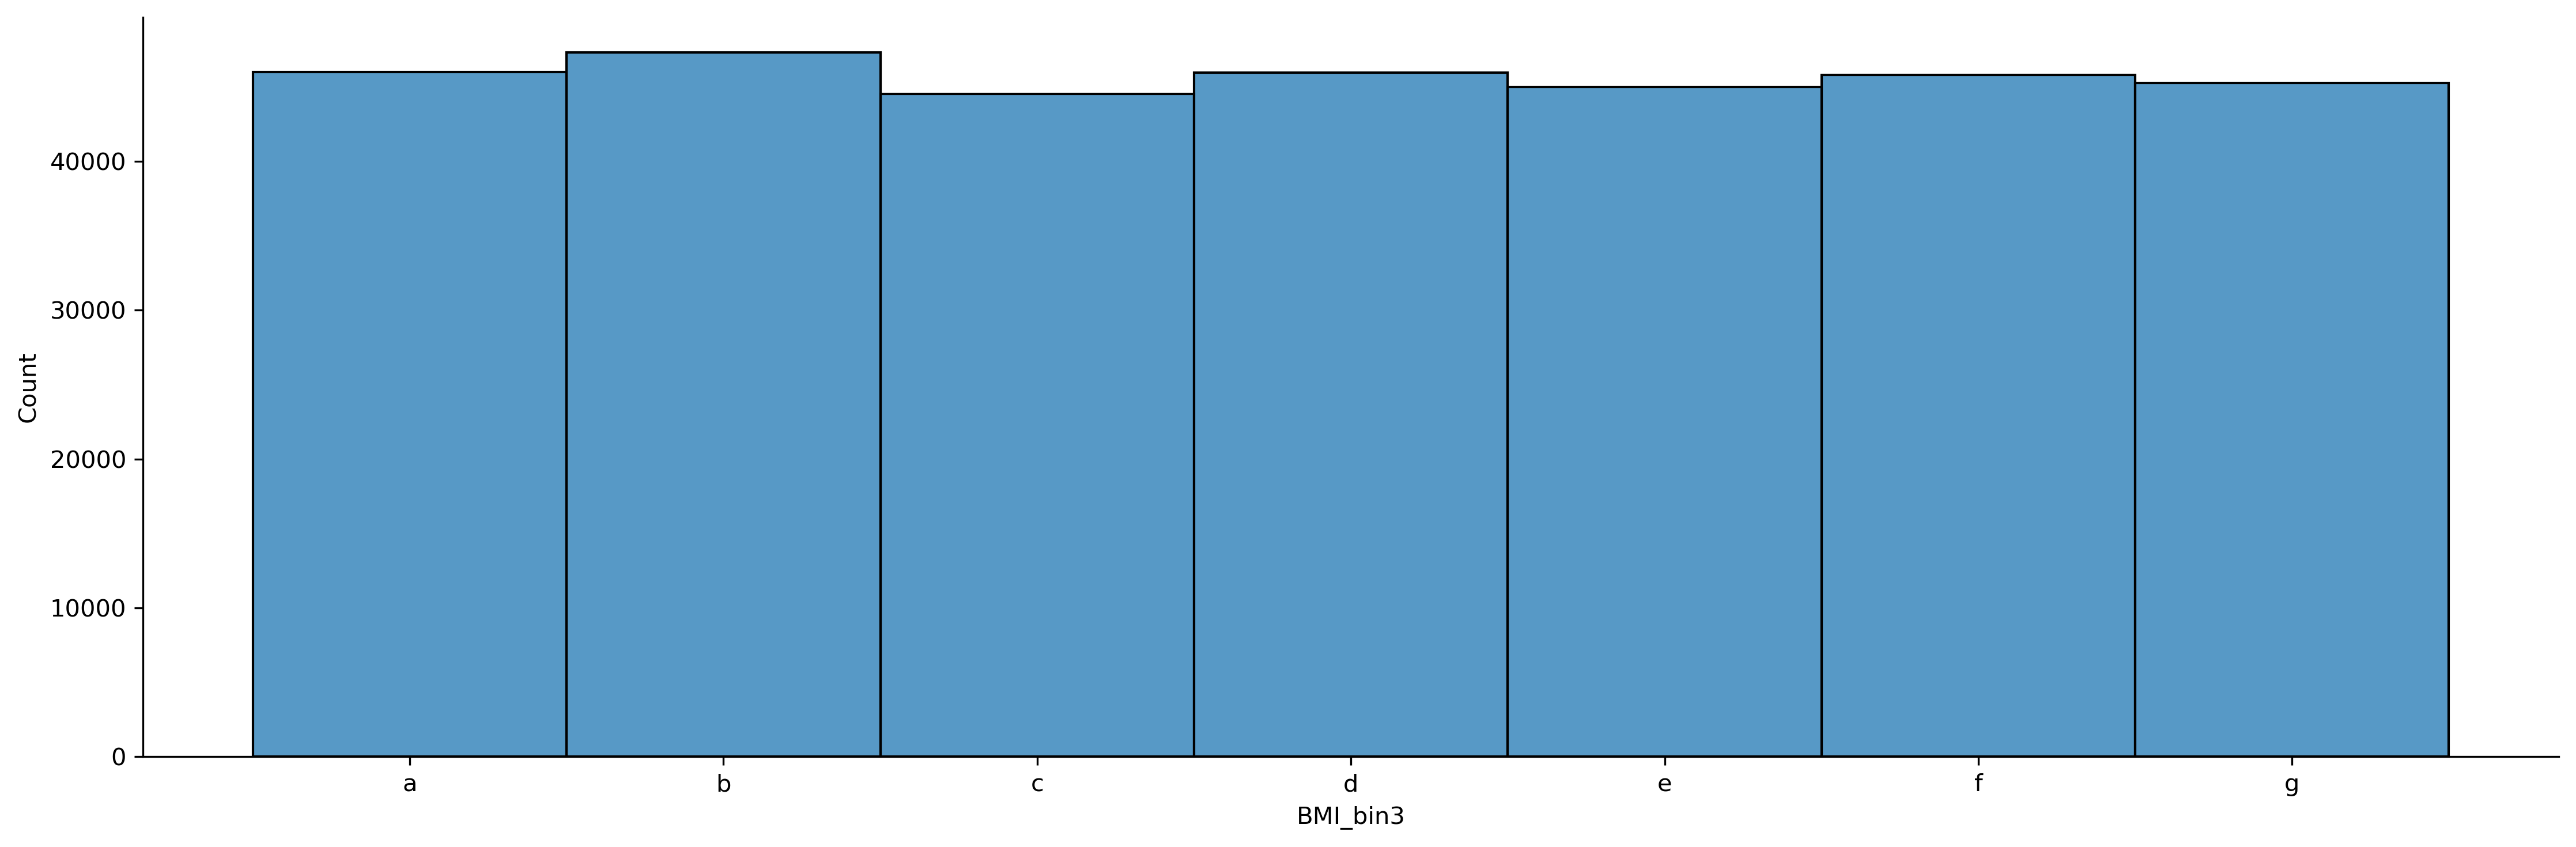

In [23]:
# BMI_bin3 분포 시각화

sns.displot(df1['BMI_bin3'],height = 5, aspect = 3)

---

다음 셀 코드 돌리기 위한 방법

In [ ]:
!pip uninstall -y xverse

# 1. 최신 xverse 재설치
!pip install xverse --quiet

# 2. 내부 binning.py 수정 (algos.quantile → np.quantile)
!cp /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning_backup.py

# algos 대신 numpy import
!sed -i 's/from pandas.core import algorithms as algos/import numpy as np/g' /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py

# algos.quantile 호출 부분 정확히 교체
!sed -i 's/algos.quantile(X, np.linspace(0, 1, force_bins))/np.quantile(X.values.flatten(), np.linspace(0, 1, force_bins))/g' /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py

Found existing installation: xverse 1.0.5
Uninstalling xverse-1.0.5:
  Successfully uninstalled xverse-1.0.5
cp: /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py: No such file or directory
sed: 1: "/usr/local/lib/python3. ...": extra characters at the end of l command
sed: 1: "/usr/local/lib/python3. ...": extra characters at the end of l command


그리고 다시 실행

---

In [ ]:
# 가중치 증거 (Weight Of Evidence, WOE)와 정보 가치 (Information Value, IV)

# WOE (Weight Of Evidence):
# 신용평가나 로지스틱 회귀 모델에서, 
# 범주형 변수의 각 구간에 대해 사건(event)과 비사건(non-event)의 비율을 로그 변환하여 계산한 값
# 이는 각 구간의 예측력을 확인하는 데 사용되며, 구간별 리스크를 정량화하는 데 유용

# IV (Information Value):
# 전체 변수의 예측력을 나타내는 값으로, WOE를 활용하여 계산
# 일반적으로 IV 값이 클수록 해당 변수의 예측력이 높다고 판단

# WOE 및 IV를 이용하여 각 구간의 예측력 및 변수 중요도를 평가하는 방법

# -----------------------------------------------------------

# WOE를 사용한 변수 구간화
df2 = df.copy()  # 데이터셋 복사

# xverse 함수 적용을 위한 더미변수 변환
df2=pd.get_dummies(df)

# 구간화 할 컬럼(X), 기준 컬럼(y) 지정
X = df2[['PhysicalHealth']]  # 독립 변수 지정
y = df2[['KidneyDisease_Yes']]  # 종속 변수 지정

# WOE 분석을 위한 종속 변수 차원 축소
y = y.T.squeeze()  # DataFrame → Series로 변환

# WOE 분석 모델 객체 생성
clf = WOE()

# 입력 변수와 타깃 변수를 기반으로 WOE 학습 수행
clf.fit(X, y)

# 각 구간의 경계값 및 WOE 값 정보 테이블 생성
a = clf.woe_df

# 변수별 Information Value(IV) 정보 테이블 생성
b = clf.iv_df

# WOE 테이블 출력
a.head()

# -----------------------------------------------------------

# 변수 'PhysicalHealth'를 기준으로 WOE 변환을 수행한 결과 요약

# Variable_Name: 분석 대상 변수명을 의미함
# Category: 해당 변수의 값이 속한 구간을 의미함. 연속형 변수를 이산형 구간으로 나눈 형태
# Count: 각 구간에 속한 총 샘플 수를 의미함
# Event: 타깃 변수(y)가 1인 샘플 수를 의미함. 예측하고자 하는 '신장 질환 있음'의 수치
# Non_Event: 타깃 변수(y)가 0인 샘플 수를 의미함. '신장 질환 없음'의 수치
# Event_Rate: 해당 구간에서 Event가 발생한 비율을 의미함. Event / Count로 계산
# Non_Event_Rate: 해당 구간에서 Non_Event가 발생한 비율을 의미함. Non_Event / Count로 계산
# Event_Distribution: 전체 Event 중 해당 구간이 차지하는 비율을 의미함
# Non_Event_Distribution: 전체 Non_Event 중 해당 구간이 차지하는 비율을 의미함
# WOE (Weight of Evidence): 로그 오즈 비율을 의미하며, 해당 변수 구간이 타깃 변수와 얼마나 관련 있는지를 나타냄
#     - WOE > 0: 해당 구간은 이벤트 발생 가능성이 높은 방향을 가짐
#     - WOE < 0: 해당 구간은 이벤트 발생 가능성이 낮은 방향을 가짐
# Information_Value: 해당 변수 전체에 대한 예측력 정보를 나타냄
#     - IV 값이 클수록 해당 변수가 타깃 예측에 기여하는 정도가 큼
#     - 일반적으로 0.3 이상이면 예측력이 강한 변수로 판단함

# 예시 해석:
# 1번 구간 (-0.001, 1.0]은 건강한 집단이 많은 구간으로 Event 비율이 낮고 WOE가 음수인 특성을 가짐
# 2번 구간 (1.0, 30.0]은 건강 문제 가능성이 높은 집단으로 Event 비율이 높고 WOE가 양수인 특성을 가짐
# 전체적으로 해당 변수는 IV = 0.3087로 강한 예측력을 가지는 변수로 평가됨




,Variable_Name,Category,Count,Event,Non_Event,Event_Rate,Non_Event_Rate,Event_Distribution,Non_Event_Distribution,WOE,Information_Value
0,PhysicalHealth,"(-0.001, 1.0]",237078,5719.0,231359.0,0.024123,0.975877,0.485525,0.751127,-0.436343,0.308774
1,PhysicalHealth,"(1.0, 30.0]",82717,6060.0,76657.0,0.073262,0.926738,0.514475,0.248873,0.726202,0.308774


In [ ]:
# Information Value 확인

b.head()

# 변수별 Information Value를 요약한 테이블 생성 결과

# Variable_Name: 분석 대상 변수명을 의미함
# Information_Value: 해당 변수의 타깃 예측 기여도를 정량적으로 측정한 지표

# 해석 기준:
# IV < 0.02      : 예측력 거의 없음
# 0.02 ≤ IV < 0.1: 약한 예측력 보유
# 0.1 ≤ IV < 0.3 : 중간 수준 예측력 보유
# IV ≥ 0.3       : 강한 예측력 보유

# 예시:
# 변수 'PhysicalHealth'의 IV는 0.308774로, 타깃 변수(KidneyDisease)에 대해 강한 예측력을 지님
# 해당 변수는 WOE 기반 이산화 및 스코어링 모델 구축 시 주요 설명 변수로 활용 가능함


,Variable_Name,Information_Value
0,PhysicalHealth,0.308774
